In [71]:
# --- Setup & Imports ---
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Setup Paths
project_root = Path('..')
xml_dir = project_root / 'data' / 'raw' / 'xmls'

In [72]:
# 2. Extract Data from XMLs
data = []
for xml_path in xml_dir.glob('*.xml'):
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        objects = root.find('objects')
        if objects is not None:
            for obj in objects.findall('object'):
                species = obj.find('name').text.strip()
                genus = species.split(' ')[0]
                data.append({'Genus': genus, 'Species': species})
    except Exception as e:
        pass # Silently skip malformed XMLs for EDA

In [73]:
# 3. Create a Pandas DataFrame
df = pd.DataFrame(data)

print(f"Total diatoms found: {len(df)}")
print(f"Unique Genera: {df['Genus'].nunique()}")
print(f"Unique Species: {df['Species'].nunique()}")

Total diatoms found: 3027
Unique Genera: 32
Unique Species: 68


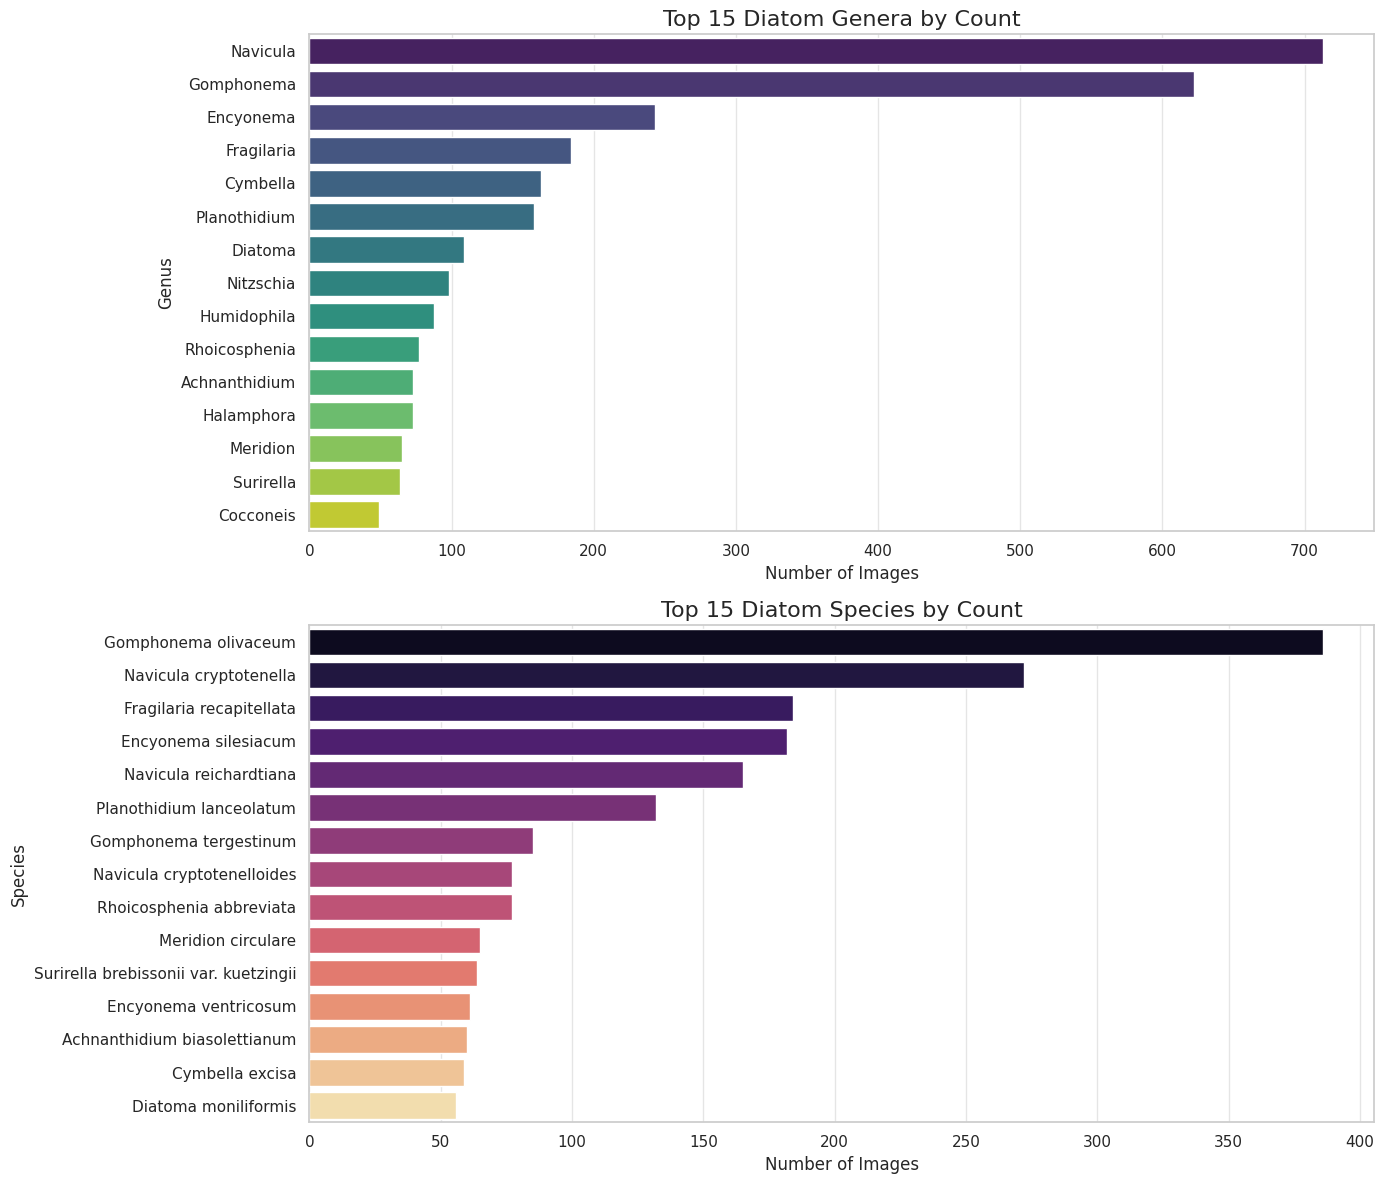

In [74]:
# 4. Visualization Setup
# We use Seaborn for cleaner, professional aesthetics
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Chart A: Top 15 Genera
genus_counts = df['Genus'].value_counts().head(15)
sns.barplot(x=genus_counts.values, y=genus_counts.index, ax=axes[0], hue=genus_counts.index, legend=False, palette="viridis")
axes[0].set_title('Top 15 Diatom Genera by Count', fontsize=16)
axes[0].set_xlabel('Number of Images')
axes[0].set_ylabel('Genus')

# Chart B: Top 15 Species
species_counts = df['Species'].value_counts().head(15)
sns.barplot(x=species_counts.values, y=species_counts.index, ax=axes[1], hue=species_counts.index, legend=False, palette="magma")
axes[1].set_title('Top 15 Diatom Species by Count', fontsize=16)
axes[1].set_xlabel('Number of Images')
axes[1].set_ylabel('Species')

plt.tight_layout()
plt.show()

In [75]:
# --- Generate Statistics CSV ---
# Group the data by Genus and Species to see how fragmented the classes are
stats_df = df.groupby(['Genus', 'Species']).size().reset_index(name='Count')

# Sort by Genus alphabetically, and then by Count descending
stats_df = stats_df.sort_values(by=['Genus', 'Count'], ascending=[True, False])

# Save to the data directory
csv_path = project_root / 'data' / 'diatom_statistics.csv'
stats_df.to_csv(csv_path, index=False)

print(f"✅ Statistics successfully saved to: {csv_path.resolve()}")

✅ Statistics successfully saved to: /home/varfo/PycharmProjects/diatom-classifier/data/diatom_statistics.csv


In [76]:
from fastai.vision.all import *

# --- Advanced Data Augmentation ---
# Diatoms have no standard orientation under a microscope.
# We apply aggressive transformations to prevent overfitting and handle class imbalance.
diatom_augs = aug_transforms(
    mult=1.0,
    do_flip=True,        # Flip horizontally
    flip_vert=True,      # Flip vertically
    max_rotate=360.0,    # Allow full 360-degree rotation
    max_zoom=1.2,        # Slight zoom variations
    max_lighting=0.3,    # Vary microscope lighting/contrast
    p_affine=0.75,       # 75% chance to apply rotation/zoom
    p_lighting=0.75      # 75% chance to apply lighting changes
)

path = project_root / 'data' / 'processed'

# The V2 DataBlock
diatom_block_v2 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    # item_tfms happen on the CPU (resizing/padding)
    item_tfms=Resize(224, method=ResizeMethod.Pad, pad_mode=PadMode.Zeros),
    # batch_tfms happen on the GPU (fast augmentations)
    batch_tfms=diatom_augs
)

In [77]:
import torch

# Force the DataLoaders to use the CPU locally to avoid driver warnings
dls_v2 = diatom_block_v2.dataloaders(path, bs=32, device=torch.device('cpu'))

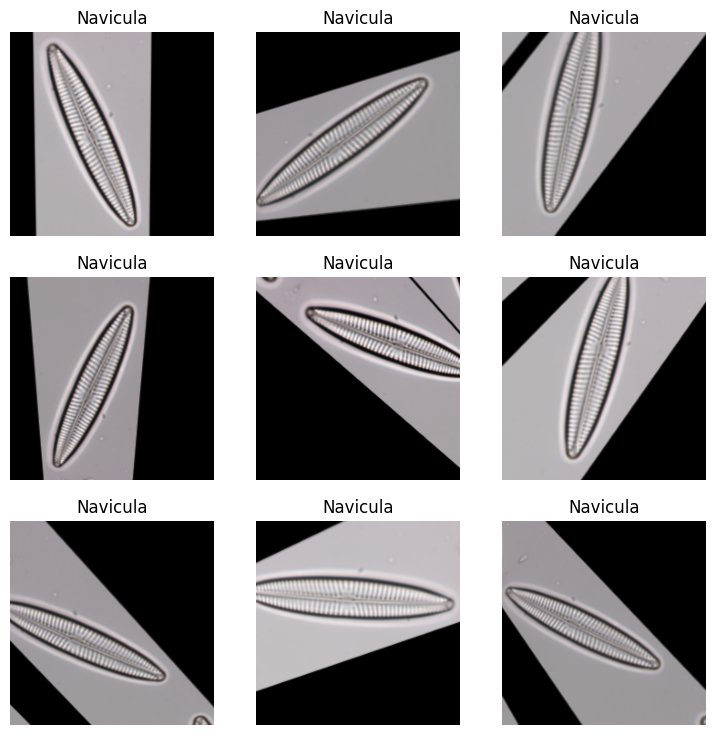

In [78]:
# Show augmented data.
dls_v2.show_batch(max_n=9, unique=True)

In [79]:
# The V2 DataBlock with Presizing
diatom_block_v2 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,

    # Step 1: Pad to a LARGER size on the CPU (Presizing)
    item_tfms=Resize(300, method=ResizeMethod.Pad, pad_mode=PadMode.Zeros),

    # Step 2: Apply rotations, then shrink to the final 224 size on the GPU
    batch_tfms=aug_transforms(
        size=224,             # Final size
        mult=1.0,
        do_flip=True,
        flip_vert=True,
        max_rotate=360.0,
        min_zoom=0.9,          # Allow slight zoom OUT to create buffer
        max_zoom=1.0,          # Prevent zooming IN (which causes clipping)
        max_lighting=0.3,
        p_affine=0.75,
        p_lighting=0.75,
        pad_mode=PadMode.Zeros # Ensures empty space from rotation stays black
    )
)

In [80]:
dls_v2 = diatom_block_v2.dataloaders(path, bs=32, device=torch.device('cpu'))

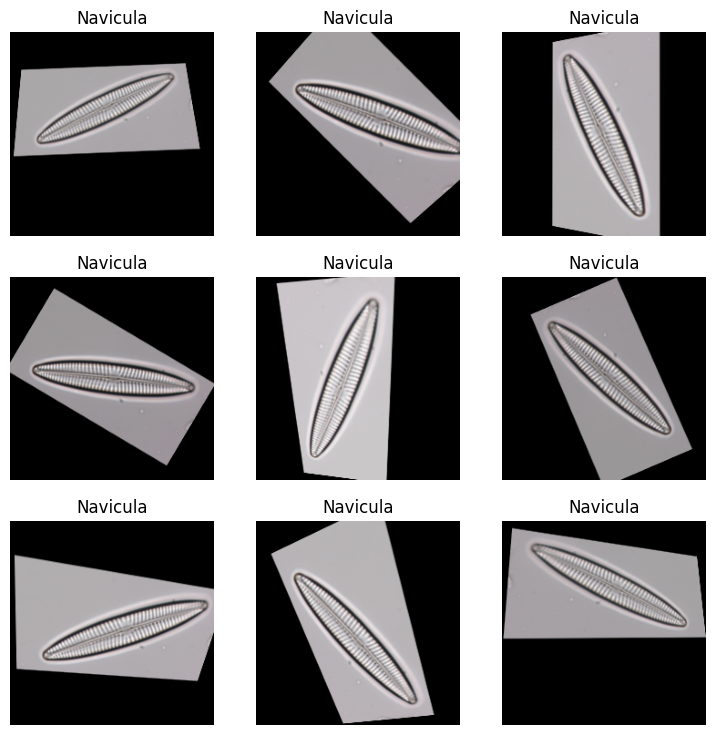

In [92]:
dls_v2.show_batch(max_n=9, unique=True)

In [93]:
from collections import Counter

# --- Class Weights Calculation ---

# 1. Count how many times each Genus appears in the TRAINING set
train_labels = [parent_label(item) for item in dls_v2.train.items]
label_counts = Counter(train_labels)

# 2. Find the count of the majority class (e.g., Gomphonema or Navicula)
max_count = max(label_counts.values())

# 3. Calculate weights: max_count / class_count
# The majority class gets a weight of 1.0.
# A class with 1/10th the images gets a weight of 10.0.
# We iterate through dls_v2.vocab to ensure the weights perfectly match Fastai's internal class order.
class_weights = [max_count / label_counts[genus] for genus in dls_v2.vocab]

# 4. Convert to a PyTorch Tensor and move it to the correct device (CPU/GPU)
weights_tensor = torch.FloatTensor(class_weights).to(dls_v2.device)

# Let's print a few to verify the math
print("Class Penalty Weights (Sample):")
for genus, weight in zip(list(dls_v2.vocab), class_weights):
    count = label_counts[genus]
    print(f"{genus:<15} | Count: {count:<4} | Penalty Weight: {weight:.2f}x")

Class Penalty Weights (Sample):
Achnanthidium   | Count: 54   | Penalty Weight: 10.48x
Adlafia         | Count: 24   | Penalty Weight: 23.58x
Amphora         | Count: 23   | Penalty Weight: 24.61x
Caloneis        | Count: 9    | Penalty Weight: 62.89x
Cocconeis       | Count: 40   | Penalty Weight: 14.15x
Cymbella        | Count: 129  | Penalty Weight: 4.39x
Cymbopleura     | Count: 5    | Penalty Weight: 113.20x
Denticula       | Count: 10   | Penalty Weight: 56.60x
Diatoma         | Count: 88   | Penalty Weight: 6.43x
Didymosphenia   | Count: 6    | Penalty Weight: 94.33x
Diploneis       | Count: 7    | Penalty Weight: 80.86x
Encyonema       | Count: 191  | Penalty Weight: 2.96x
Epithemia       | Count: 20   | Penalty Weight: 28.30x
Fragilaria      | Count: 152  | Penalty Weight: 3.72x
Frustulia       | Count: 12   | Penalty Weight: 47.17x
Gomphonema      | Count: 501  | Penalty Weight: 1.13x
Halamphora      | Count: 59   | Penalty Weight: 9.59x
Hantzschiana    | Count: 8    | Penalt

In [95]:
# --- Initialize the V2 Learner ---
# We build the model and explicitly replace its loss function with our weighted version
learn_v2 = vision_learner(dls_v2, resnet18, metrics=accuracy)
learn_v2.loss_func = CrossEntropyLossFlat(weight=weights_tensor)

print("\n✅ Learner initialized with weighted loss function.")


✅ Learner initialized with weighted loss function.


In [96]:
train_labels = [parent_label(item) for item in dls_v2.train.items]
label_counts = Counter(train_labels)
max_count = max(label_counts.values())

# Define a maximum penalty to prevent gradient explosions
MAX_WEIGHT = 15.0

# Calculate weights and apply the cap using min()
class_weights = [min(MAX_WEIGHT, max_count / label_counts[genus]) for genus in dls_v2.vocab]

weights_tensor = torch.FloatTensor(class_weights).to(dls_v2.device)

# Initialize the Learner with the smoothed weights
learn_v2 = vision_learner(dls_v2, resnet18, metrics=accuracy)
learn_v2.loss_func = CrossEntropyLossFlat(weight=weights_tensor)

print("\n✅ Learner initialized with SMOOTHED weighted loss function.")


✅ Learner initialized with SMOOTHED weighted loss function.


In [97]:
print("Class Penalty Weights (Sample):")
for genus, weight in zip(list(dls_v2.vocab), class_weights):
    count = label_counts[genus]
    print(f"{genus:<15} | Count: {count:<4} | Penalty Weight: {weight:.2f}x")

Class Penalty Weights (Sample):
Achnanthidium   | Count: 54   | Penalty Weight: 10.48x
Adlafia         | Count: 24   | Penalty Weight: 15.00x
Amphora         | Count: 23   | Penalty Weight: 15.00x
Caloneis        | Count: 9    | Penalty Weight: 15.00x
Cocconeis       | Count: 40   | Penalty Weight: 14.15x
Cymbella        | Count: 129  | Penalty Weight: 4.39x
Cymbopleura     | Count: 5    | Penalty Weight: 15.00x
Denticula       | Count: 10   | Penalty Weight: 15.00x
Diatoma         | Count: 88   | Penalty Weight: 6.43x
Didymosphenia   | Count: 6    | Penalty Weight: 15.00x
Diploneis       | Count: 7    | Penalty Weight: 15.00x
Encyonema       | Count: 191  | Penalty Weight: 2.96x
Epithemia       | Count: 20   | Penalty Weight: 15.00x
Fragilaria      | Count: 152  | Penalty Weight: 3.72x
Frustulia       | Count: 12   | Penalty Weight: 15.00x
Gomphonema      | Count: 501  | Penalty Weight: 1.13x
Halamphora      | Count: 59   | Penalty Weight: 9.59x
Hantzschiana    | Count: 8    | Penalty

<div></div>

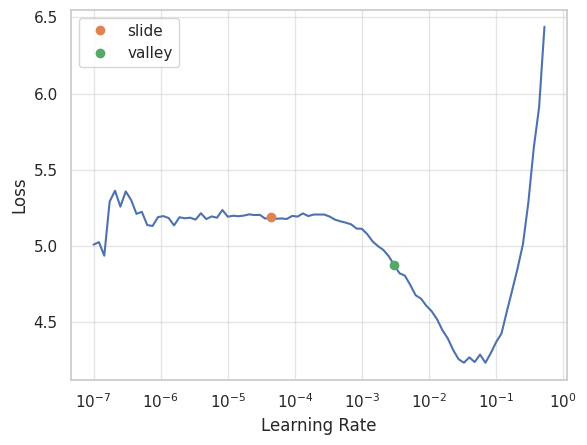

In [98]:
# --- Find the Optimal Learning Rate ---
# We run lr_find() to visually inspect where the model learns best.
# suggest_funcs gives us the steepest slope (slide) and the minimum divided by 10 (valley)

lr_result = learn_v2.lr_find(suggest_funcs=(slide, valley))

In [99]:
lr_result

SuggestedLRs(slide=4.365158383734524e-05, valley=0.0030199517495930195)

In [100]:
# --- Train the V2 Model ---
# We pass our chosen learning rate (the valley: 0.003) to fine_tune.
# We are training for 8 epochs to allow the model to learn from the augmented data.

optimal_lr = 0.003

# fine_tune handles freezing and unfreezing the neural network automatically
learn_v2.fine_tune(8, base_lr=optimal_lr)

epoch,train_loss,valid_loss,accuracy,time
0,2.923821,1.480711,0.611570,00:58


epoch,train_loss,valid_loss,accuracy,time
0,1.361087,0.838044,0.750413,01:20
1,1.059672,0.600726,0.811570,01:21
2,0.890777,0.515246,0.834711,01:22
3,0.731675,0.334714,0.877686,01:21
4,0.478801,0.214139,0.919008,01:23
5,0.308509,0.173649,0.928926,01:23
6,0.247089,0.114452,0.943802,01:23
7,0.181428,0.108549,0.940496,01:22


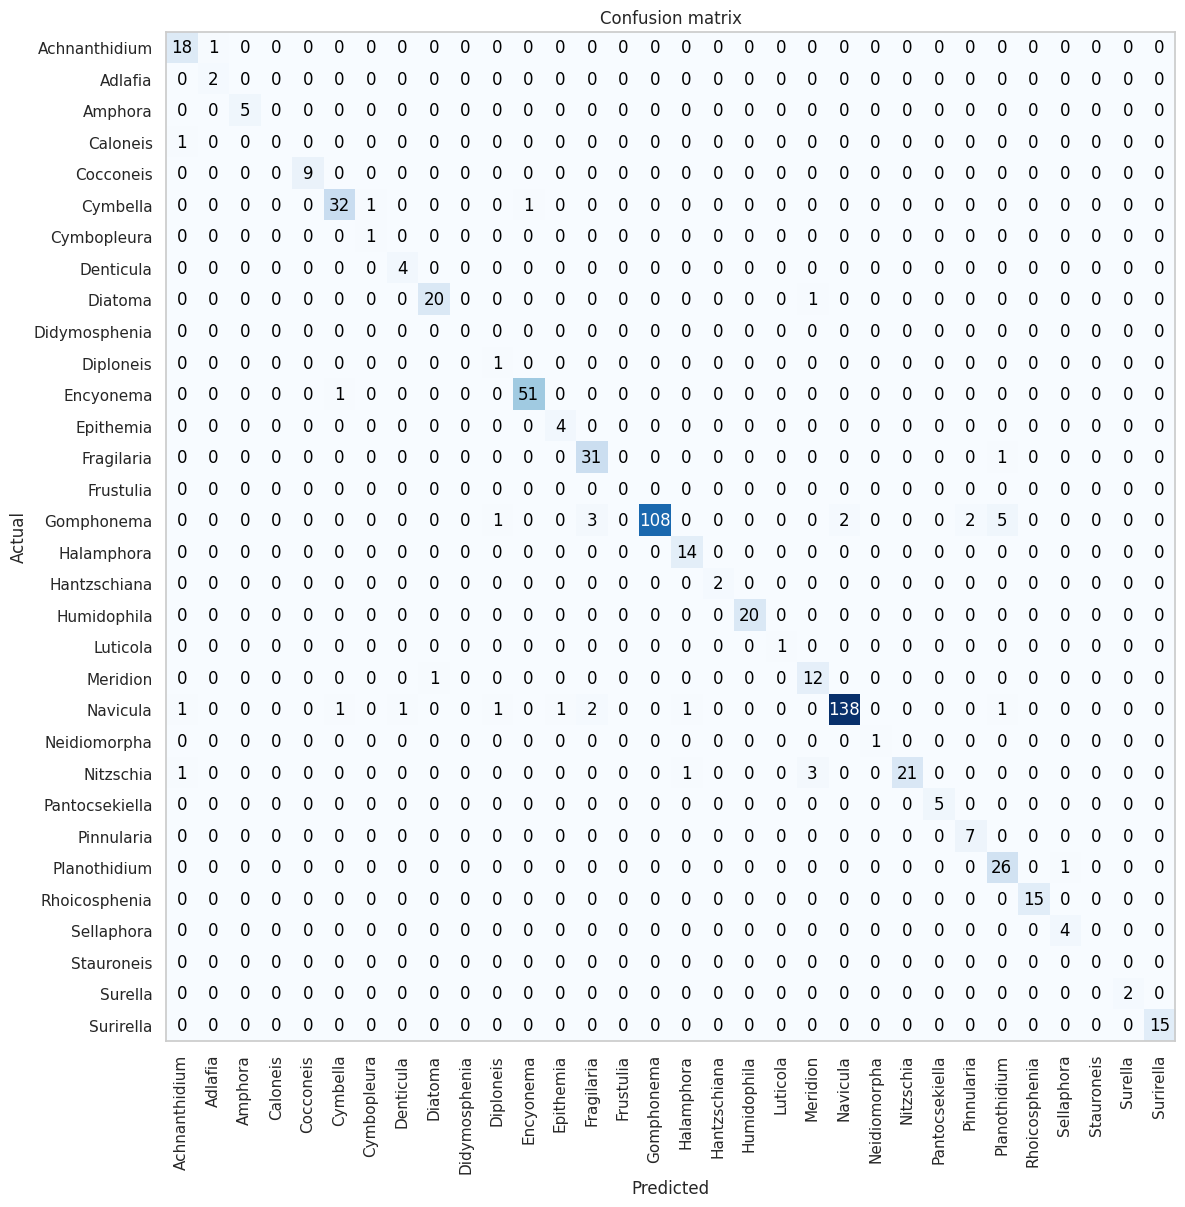

In [101]:
# --- V2 Evaluation ---
interp_v2 = ClassificationInterpretation.from_learner(learn_v2)
interp_v2.plot_confusion_matrix(figsize=(12, 12))

In [102]:
# --- Save the V2 Model ---
model_dir = project_root / 'models'
v2_model_path = model_dir / 'v2_resnet18_weighted.pkl'
learn_v2.export(v2_model_path)
print(f"✅ V2 Model successfully saved to {v2_model_path.resolve()}")

✅ V2 Model successfully saved to /home/varfo/PycharmProjects/diatom-classifier/models/v2_resnet18_weighted.pkl
